## **Variables correlation**

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
EEA = pd.read_csv('reduced_EEA_2023.csv')

In [3]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Engine_Capacity(cm3),Engine_Power(kW)
0,1175.0,129.0,petrol,999.0,70.0
1,1122.0,117.0,petrol,999.0,59.0
2,1588.0,126.0,diesel,1968.0,110.0
3,1516.0,124.0,diesel,1968.0,110.0
4,1349.0,126.0,petrol,1498.0,110.0


In [4]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Mass_in_Running_Order(kg)  75530 non-null  float64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  float64
 2   Fuel_Type                  75530 non-null  object 
 3   Engine_Capacity(cm3)       75530 non-null  float64
 4   Engine_Power(kW)           75530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 2.9+ MB


So, we have 4 numerical values and one categorical

we should look at the distribution of our numerical features so we can know which scaler to apply

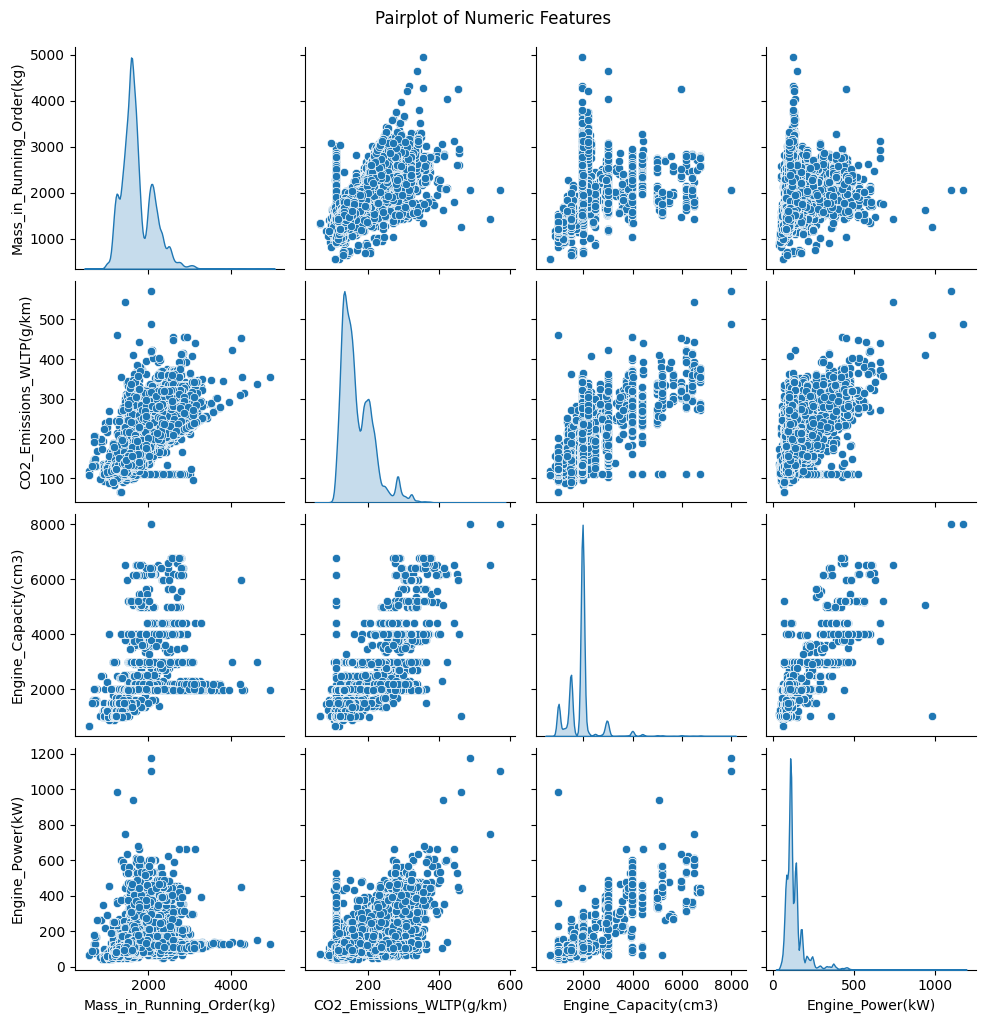

In [5]:
sns.pairplot(EEA, diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()


Mass:
 - Distribution: Right-skewed (positive skew)
 - Observations:
    - Clustered around 1000–2000 kg
    - Long tail to heavier vehicles (>2000 kg)
    - Likely outliers in the upper range

Engine capacity: 
  - Distribution: Right-skewed, but not heavily
  - Observations:
    - Looks like it has discrete bands. This is because vehicles share the exact same engine size due to the design norms, even though it’s a continuous variable
    - Clustering around typical engine sizes (1000, 1600, 2000, 3000 cm³)
    - Gaps between these clusters — not a smooth histogram

Engine_Power(kW):
  - Distribution: Heavily right skweed
  - Observations: 
    - Most vehicles are in the 50–150 kW range
    - Extreme outliers above 300–400 kW (likely high-performance cars)
    - These outliers will influence most models

 CO2_Emissions_WLTP(g/km):
  - Distribution: Also right-skewed
  - Observations:
    - Many vehicles emit between 100–200 g/km
    - Some go well above 250–300 g/km












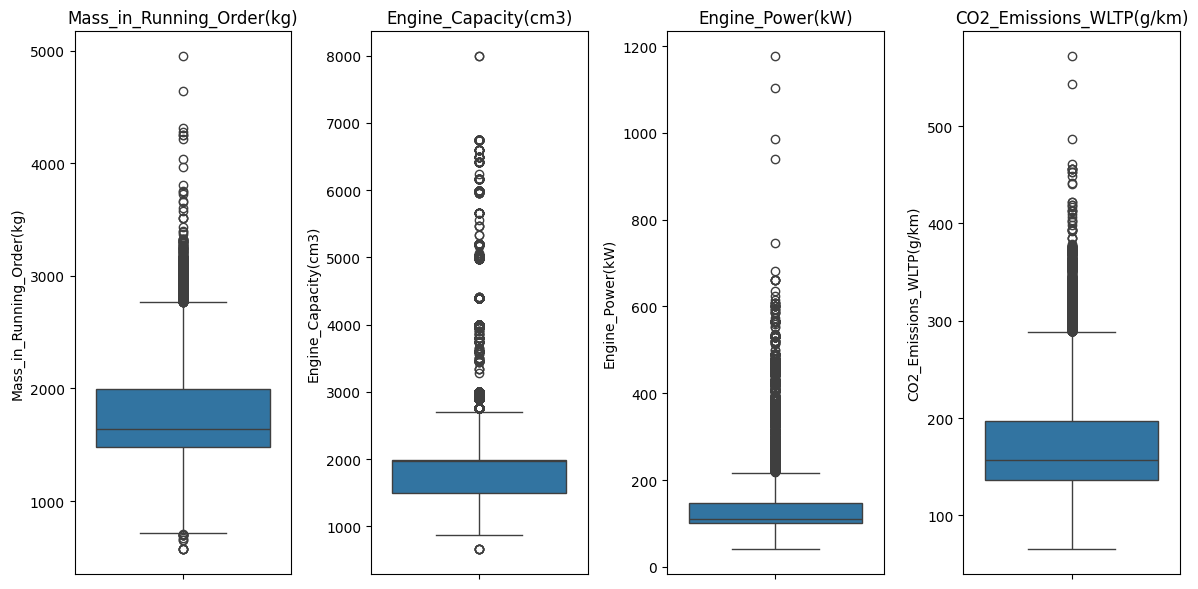

In [6]:


numeric_cols = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 
                'Engine_Power(kW)', 'CO2_Emissions_WLTP(g/km)']

#distribution boxplot graphing
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=EEA[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

### What does the Fuel type distribution look like?

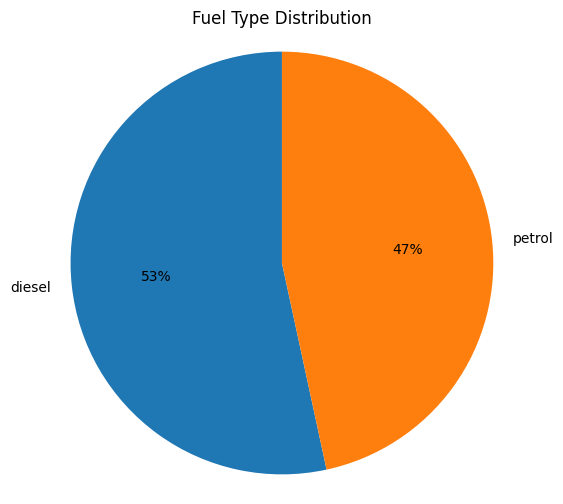

In [7]:
#obtaining value counts
fuel_counts = EEA['Fuel_Type'].value_counts(normalize=True)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.0f%%', startangle=90)
plt.title('Fuel Type Distribution')
plt.axis('equal')  
plt.show()

Let's explore how our variables are explaining our target

## Categorical into dummies

In [8]:
EEA = pd.get_dummies(EEA, columns=['Fuel_Type'], drop_first=True)

In [9]:
EEA = EEA.astype(int)

In [10]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
0,1175,129,999,70,1
1,1122,117,999,59,1
2,1588,126,1968,110,0
3,1516,124,1968,110,0
4,1349,126,1498,110,1


In [11]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Mass_in_Running_Order(kg)  75530 non-null  int64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  int64
 2   Engine_Capacity(cm3)       75530 non-null  int64
 3   Engine_Power(kW)           75530 non-null  int64
 4   Fuel_Type_petrol           75530 non-null  int64
dtypes: int64(5)
memory usage: 2.9 MB


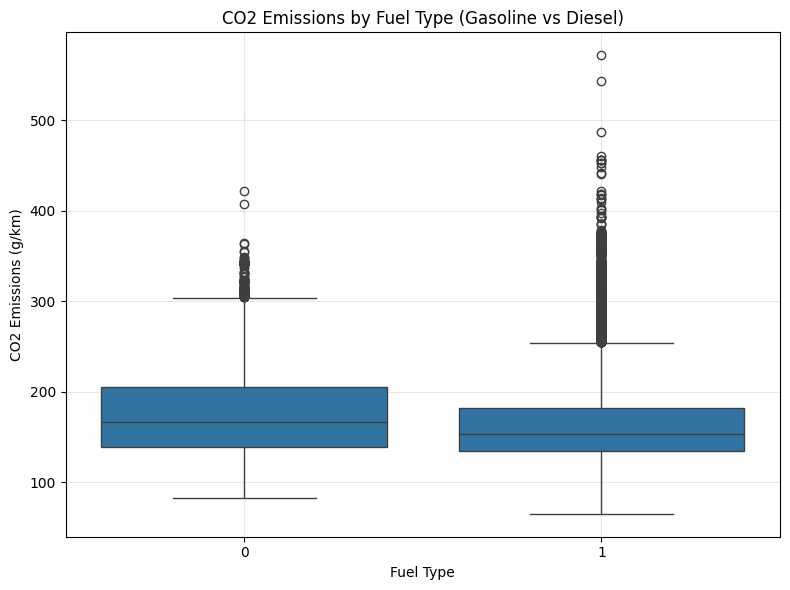

In [12]:
#boxplot graphing
plt.figure(figsize=(8, 6))
sns.boxplot(x='Fuel_Type_petrol', y='CO2_Emissions_WLTP(g/km)', data=EEA)
plt.title('CO2 Emissions by Fuel Type (Gasoline vs Diesel)')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
#comparing groups of diesel and gasoline
EEA.groupby('Fuel_Type_petrol')['CO2_Emissions_WLTP(g/km)'] \
  .agg(['median', 'mean', 'count', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])

,median,mean,count,<lambda_0>,<lambda_1>
Fuel_Type_petrol,,,,,
0,167.0,174.777973,40324,139.0,205.0
1,153.0,164.860137,35206,134.0,182.0


Petrol vehicles have a median CO₂ of 174.8 g/km, which is higher than diesel’s median of 164.9 g/km. 

In [14]:
EEA.groupby('Fuel_Type_petrol')['Mass_in_Running_Order(kg)'] \
  .agg(['median', 'mean', 'count', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])

,median,mean,count,<lambda_0>,<lambda_1>
Fuel_Type_petrol,,,,,
0,1783.0,1896.748884,40324,1611.0,2142.0
1,1525.0,1535.282821,35206,1335.0,1671.0


On average, petrol cars in the dataset are lighter, that could be the reason why petrol cars have a lower CO2 median consumption

## Model 1 - Linear Regression

In [15]:
#defining x and y
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [16]:
#splitting database
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler_lin = StandardScaler()

# Define which numerical features need scaling
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

# Make copies of the training and test datasets (to avoid modifying original data)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit the scaler on the training set and transform it (standardize training data)
X_train_scaled[features_to_scale] = scaler_lin.fit_transform(X_train[features_to_scale])

# Use the same scaler (already fitted on training data) to transform the test set
X_test_scaled[features_to_scale] = scaler_lin.transform(X_test[features_to_scale])



Train MSE (LR): 364.62
Test MSE (LR): 373.25
Train MAE (LR): 12.03
Test MAE (LR): 12.02
Train RMSE (LR): 19.10
Test RMSE (LR): 19.32
Train R² Score (LR): 0.816
Test R² Score (LR): 0.811


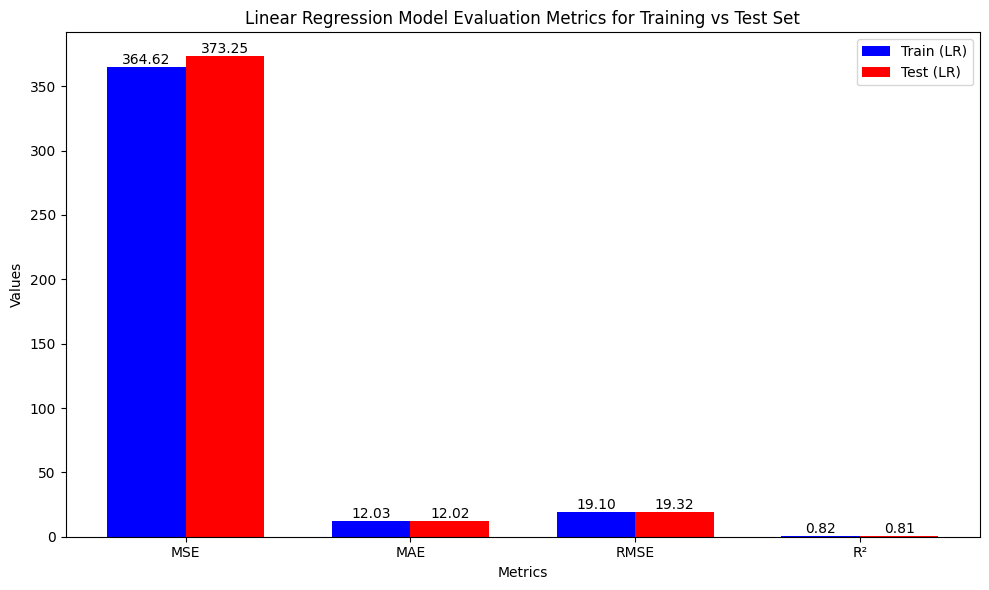

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train Linear Regression model using scaled training data
lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

# Predict target values for both train and test sets
y_train_pred_lr = lr_model_scaled.predict(X_train_scaled)
y_test_pred_lr = lr_model_scaled.predict(X_test_scaled)

# Calculate Error Metrics 
#MSE
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)

#MAE
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

#RMSE
train_mrse_lr = np.sqrt(train_mse_lr)
test_mrse_lr = np.sqrt(test_mse_lr)

# R2
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

#  Print Results 
print(f"Train MSE (LR): {train_mse_lr:.2f}")
print(f"Test MSE (LR): {test_mse_lr:.2f}")
print(f"Train MAE (LR): {train_mae_lr:.2f}")
print(f"Test MAE (LR): {test_mae_lr:.2f}")
print(f"Train RMSE (LR): {train_mrse_lr:.2f}")
print(f"Test RMSE (LR): {test_mrse_lr:.2f}")
print(f"Train R² Score (LR): {train_r2_lr:.3f}")
print(f"Test R² Score (LR): {test_r2_lr:.3f}")


#  Prepare Data for Visualization 
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values_lr = [train_mse_lr, train_mae_lr, train_mrse_lr, train_r2_lr]
test_values_lr = [test_mse_lr, test_mae_lr, test_mrse_lr, test_r2_lr]

bar_width = 0.35
index = np.arange(len(metrics))

#  Plot Metrics Comparison 
plt.figure(figsize=(10, 6))
plt.bar(index, train_values_lr, bar_width, label='Train (LR)', color='blue')
plt.bar(index + bar_width, test_values_lr, bar_width, label='Test (LR)', color='red')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Linear Regression Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

for i, value in enumerate(train_values_lr):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values_lr):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    37.240262
3           Fuel_Type_petrol    22.820005
2           Engine_Power(kW)    10.870419
1       Engine_Capacity(cm3)     0.912619


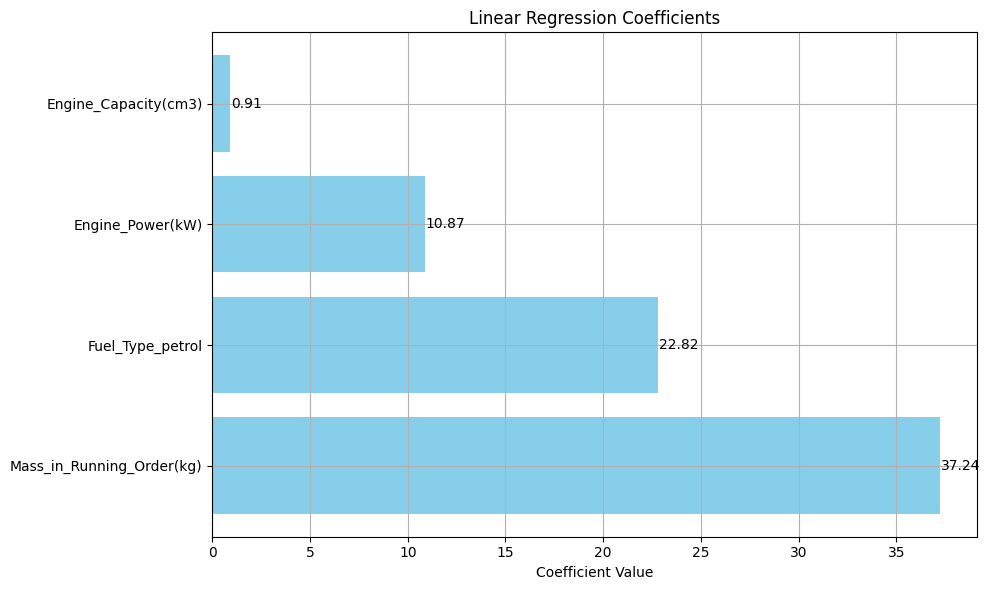

In [19]:
# Create a DataFrame of model coefficients linked to feature names
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model_scaled.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

#graph arrangements
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# ---- Compare Train and Test R² Scores ----
# Calculate the absolute difference between train and test R²
train_test_diff = abs(train_r2_lr - test_r2_lr)

# Print R² values and their difference
print(f"Train R²: {train_r2_lr:.3f}")
print(f"Test R²: {test_r2_lr:.3f}")
print(f"R² Difference: {train_test_diff:.3f}")

#  Interpret Results 
if train_test_diff > 0.05:
    # If the gap between train and test R² is large, the model is likely overfitting
    print("Potential overfitting detected")
elif test_r2_lr > train_r2_lr:
    # If test performs better than train, it means strong generalization (rare but possible)
    print("No overfitting - good generalization")
else:
    # If scores are close, the model fits well without much overfitting
    print("Good fit - minimal overfitting")

Train R²: 0.816
Test R²: 0.811
R² Difference: 0.005
Good fit - minimal overfitting


- R² Score: 0.81
    - This means 81% of the variance in CO₂ emissions is explained by the model. That’s a strong result for a linear model, especially considering the simplicity and interpretability.

- MSE: 373.25

    - The root of Mean Squared Error is 19.3, so the model predicts around 12% off the actual value, this MSE seems reasonable.

The model generalizes well and isn't heavily overfitting as the R2 difference is 0.005.

- Mass_in_Running_Order is the Strongest predictor. Heavier vehicles emit more CO₂
- The next strongest predictor is Fuel_Type_petrol. Petrol cars emit significantly more than diesel (since "petrol = 1")
- The weakest impact is the Engine_Capacity(cm3), which indicates that might be redundant with power or mass

#### Saving the Model for Streamlit

In [21]:
import joblib

# Save the scaler
joblib.dump(scaler_lin, '../models/scaler_lin.pkl')

# Save the model
joblib.dump(lr_model_scaled, '../models/linear_regression_model.pkl')

['../models/linear_regression_model.pkl']

## Model 2 - Lasso model

In [22]:
#importing Lasso
from sklearn.linear_model import Lasso

In [23]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [24]:
#splitting database
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
#  Standardize Features for Lasso Regression 
scaler_lasso = StandardScaler()   # Initialize a StandardScaler instance

# Select the numerical features that need scaling
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

# Make copies of training and test datasets (so originals remain unchanged)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit the scaler on the training data and transform it (standardization: mean=0, std=1)
X_train_scaled[features_to_scale] = scaler_lasso.fit_transform(X_train[features_to_scale])

# Apply the same scaler (fitted on training data) to transform the test data
X_test_scaled[features_to_scale] = scaler_lasso.transform(X_test[features_to_scale])

In [26]:
# Train Lasso Regression Model

# Initialize Lasso Regression with alpha=0.1 (regularization strength)
lasso_model = Lasso(alpha=0.1, random_state=42)

# Fit the model on the scaled training data
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


Lasso Test MSE: 373.32
Lasso Test MAE: 12.02
Lasso Test RMSE: 19.32
Lasso Test R²: 0.811


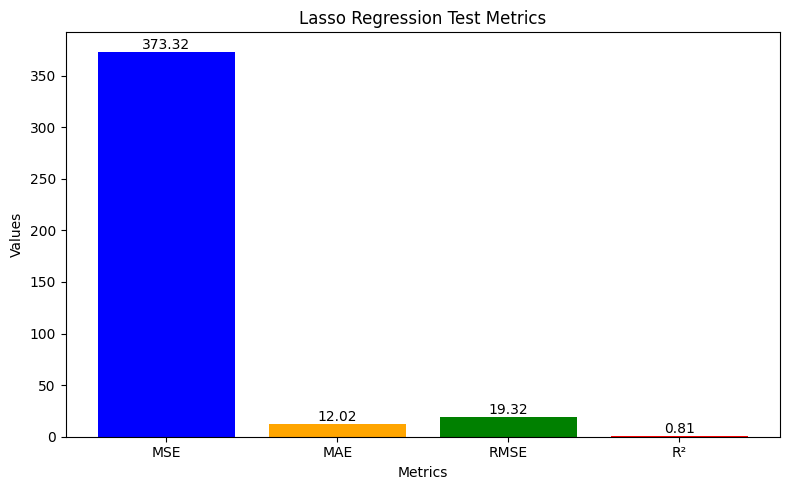

In [27]:
# Make Predictions on Test Data 
y_pred = lasso_model.predict(X_test_scaled)

# Calculate Evaluation Metrics 
mse = mean_squared_error(y_test, y_pred)      
mae = mean_absolute_error(y_test, y_pred)     
rmse = np.sqrt(mse)                           
r2 = r2_score(y_test, y_pred)                 

# Print Evaluation Metrics 
print(f"Lasso Test MSE: {mse:.2f}")
print(f"Lasso Test MAE: {mae:.2f}")
print(f"Lasso Test RMSE: {rmse:.2f}")
print(f"Lasso Test R²: {r2:.3f}")

# Prepare Data for Visualization 
metrics = ['MSE', 'MAE', 'RMSE', 'R²']   
values = [mse, mae, rmse, r2]            

# Create a Bar Plot 
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])

#  Add Metric Values on Top of Bars 
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

# Add Labels and Title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Lasso Regression Test Metrics')

# graphing adjustments
plt.tight_layout()   
plt.show()    

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    36.971072
3           Fuel_Type_petrol    21.985693
2           Engine_Power(kW)    11.147560
1       Engine_Capacity(cm3)     0.661750


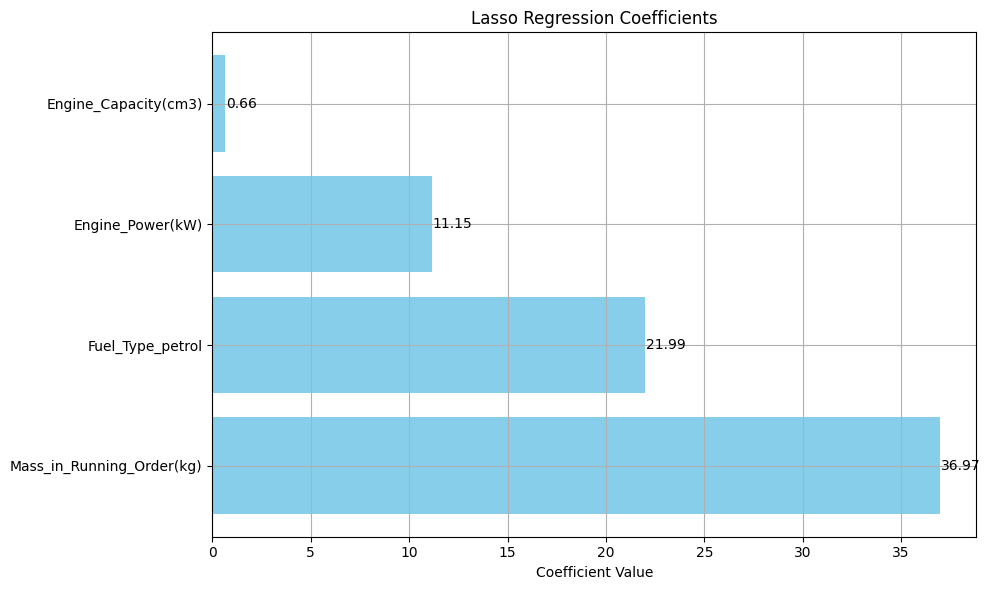

In [28]:
# Extract Lasso Coefficients 
coefficients = pd.DataFrame({
    'Feature': X.columns,                   
    'Coefficient': lasso_model.coef_        
}).sort_values(by='Coefficient', key=abs, ascending=False)  # Sort by absolute importance

print(coefficients)

# Plotting the Coefficients
plt.figure(figsize=(10, 6))   
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')  

# Add coefficient values on bars 
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')  


# Labels and Title 
plt.xlabel('Coefficient Value')  
plt.title('Lasso Regression Coefficients')  

# graph adjustments
plt.grid(True)         
plt.tight_layout()     
plt.show()             

Best alpha: 0.0012648552168552957
Test MSE: 373.2502988016058
Lasso Test RMSE: 19.32
Test R²: 0.8111775248805912


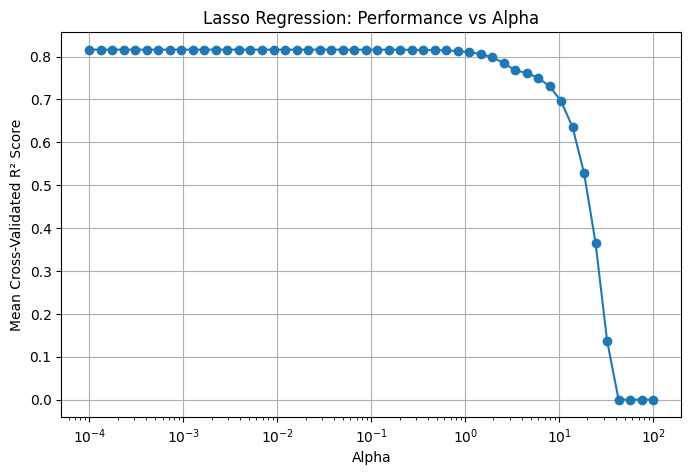

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Define Lasso model and alpha grid
lasso = Lasso(max_iter=10000)
alphas = {'alpha': np.logspace(-4, 2, 50)}  

# Grid search for best alpha
grid = GridSearchCV(lasso, alphas, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

# Best model evaluation
best_lasso = grid.best_estimator_
y_pred = best_lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mrse = np.sqrt(mse)

print("Best alpha:", grid.best_params_['alpha'])
print("Test MSE:", mse)
print(f"Lasso Test RMSE: {mrse:.2f}")
print("Test R²:", r2)

# Plot alpha vs CV R²
plt.figure(figsize=(8, 5))
plt.semilogx(alphas['alpha'], grid.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean Cross-Validated R² Score')
plt.title('Lasso Regression: Performance vs Alpha')
plt.grid(True)
plt.show()



The results are very similar to Linear Model above.

#### Saving the model for Streamlit

In [30]:
# Save the scaler
joblib.dump(scaler_lasso, '../models/scaler_lasso.pkl')

# Save the model
joblib.dump(lasso_model, '../models/lasso_model.pkl')

['../models/lasso_model.pkl']

## Model 3 - RandomForestRegressor 

RandomForestRegressor does not require scaling or normalization

Test MSE: 131.69
Test MAE: 4.96
Test RMSE: 11.48
Test R² Score: 0.933


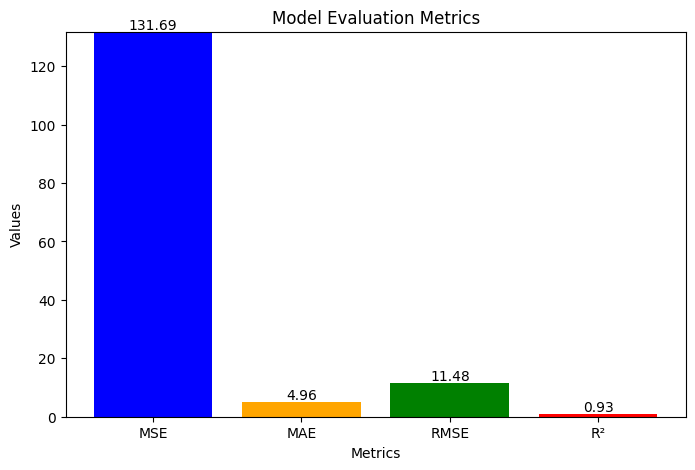

In [31]:
from sklearn.ensemble import RandomForestRegressor


# Define features (X) and target (y)
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict values on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

# Print metrics
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.3f}")

# Prepare metrics for plotting
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, rmse, r2]

# Create a bar plot of metrics
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust y-axis to leave space above bars
plt.ylim([0, max(values) + 0.1])

# Add metric values above bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

plt.show()

R² score of 0.93 is very good, because it means that the model can explain 93% of the data variance. 
The MSE of 131.69, so the RMSE is 11.48 g/km, this means that on average, your model's prediction is  around 11.5 g/km or 6% off from the true CO₂ emission value. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 62.32
Test MSE: 131.69
Train MAE: 3.97
Test MAE: 4.96
Train RMSE: 7.89
Test RMSE: 11.48
Train R² Score: 0.969
Test R² Score: 0.933


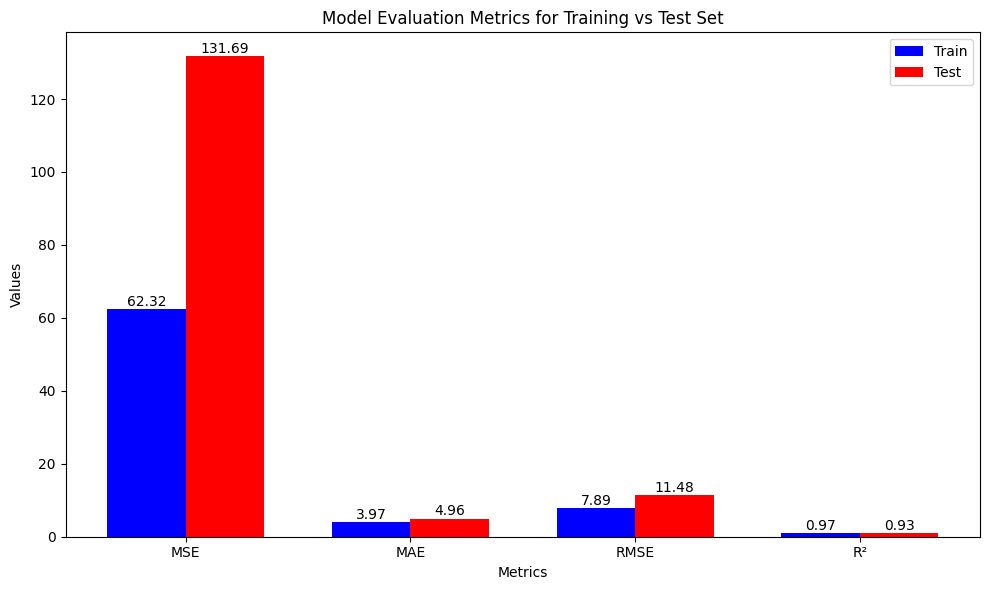

In [32]:
# Predict on both training and test sets
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Compute Mean Squared Error (MSE) for train and test
train_mse = mean_squared_error(y_train, y_train_pred_rf)
test_mse = mean_squared_error(y_test, y_test_pred_rf)

# Compute Mean Absolute Error (MAE) for train and test
train_mae = mean_absolute_error(y_train, y_train_pred_rf)
test_mae = mean_absolute_error(y_test, y_test_pred_rf)

# Compute Root Mean Squared Error (RMSE) as sqrt(MSE)
train_mrse = np.sqrt(train_mse)   # RMSE on training set
test_mrse = np.sqrt(test_mse)     # RMSE on test set

# Compute R2 scores (explained variance) for train and test
train_r2 = r2_score(y_train, y_train_pred_rf)
test_r2 = r2_score(y_test, y_test_pred_rf)

# Print all metrics with formatting
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# Prepare values for a grouped bar chart
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Bar positions and width
bar_width = 0.35
index = np.arange(len(metrics))

# Plot grouped bars
plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Labels, title, ticks, legend
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Add value labels above each bar
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.97 shows it explains 97% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.93, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

In oder to get a higher confidence in our results, we perform a cross-validation

In [33]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the training set using R^2 as the scoring metric
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

# Print all cross-validation R^2 scores for the folds
print(f"Cross-validated R² scores: {cv_scores}")

# Print the mean R^2 score across all folds
print(f"Mean CV R² score: {cv_scores.mean():.3f}")

Cross-validated R² scores: [0.93869596 0.93664242 0.92828702 0.92932125 0.9337159 ]
Mean CV R² score: 0.933


- Consistent performance: Scores range from 0.928 to 0.939. This suggests model's performance is very good across different data splits.

- No severe overfitting:
    Test R² (0.93), train R² (0.97), and CV R² (0.93) are all close. The R² difference (0.04) is acceptable and suggests minimal overfitting.

- Model status: The overall performance of the model is strong. The model is well fitted and generalizes well. 

#### Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2],
}

rf = RandomForestRegressor(random_state=42)

# Set up grid search with cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)

# Show best hyperparameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated R² score: 0.9351930979480934


In [35]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

# Retrieve the best model from grid search
best_model_Random_Forest = grid_search.best_estimator_

# Predictions for train and test sets
y_train_pred_rf = best_model_Random_Forest.predict(X_train)
y_test_pred_rf = best_model_Random_Forest.predict(X_test)

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred_rf)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred_rf)
train_r2 = r2_score(y_train, y_train_pred_rf)

# Test metrics
test_mse = mean_squared_error(y_test, y_test_pred_rf)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred_rf)
test_r2 = r2_score(y_test, y_test_pred_rf)

# Print results
print("\nFine-tuned Model Performance:")
print(f"Train MSE: {train_mse:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest MSE: {test_mse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R²: {test_r2:.3f}")


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated R² score: 0.9351930979480934

Fine-tuned Model Performance:
Train MSE: 75.933
Train RMSE: 8.714
Train MAE: 4.353
Train R²: 0.962

Test MSE: 128.456
Test RMSE: 11.334
Test MAE: 5.053
Test R²: 0.935


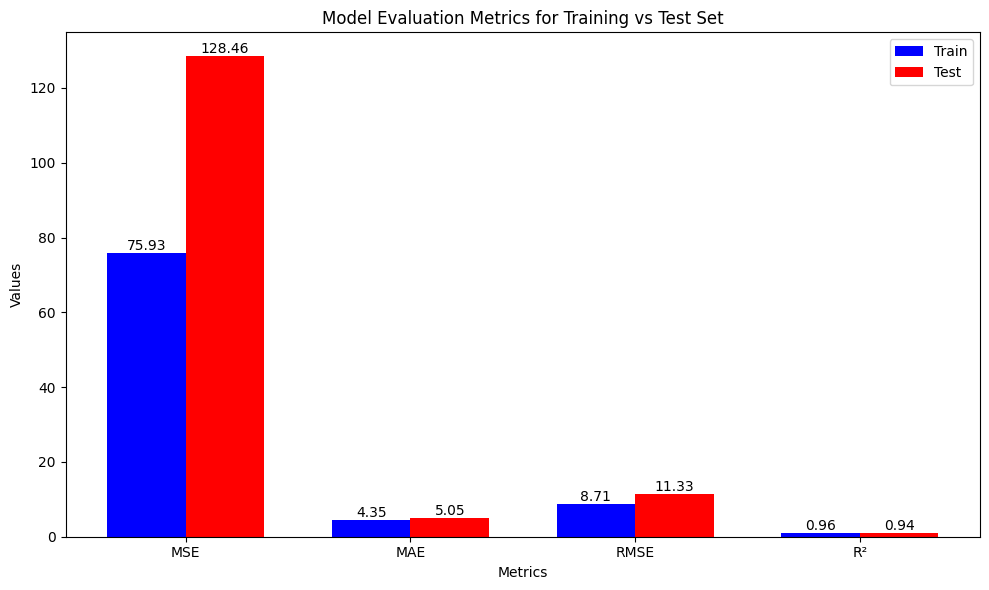

In [36]:
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_rmse, train_r2]
test_values = [test_mse, test_mae, test_rmse, test_r2]

# Set bar width and positions
bar_width = 0.35
index = np.arange(len(metrics))

# Create bar plot for train vs test metrics
plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Labels, title, and ticks
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Add metric values on top of bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

Model Comparison and Evaluation

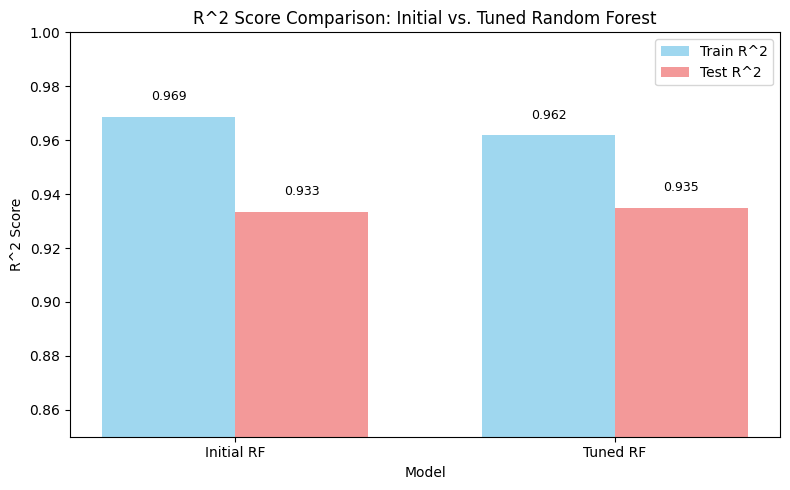

In [37]:
# Calculate R^2 scores for the initial and tuned Random Forest models
initial_train_r2 = r2_score(y_train, rf_model.predict(X_train))
initial_test_r2 = r2_score(y_test, rf_model.predict(X_test))
tuned_train_r2 = r2_score(y_train, best_model_Random_Forest.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_model_Random_Forest.predict(X_test))

# Create a DataFrame to store comparison results
comparison_df = pd.DataFrame({
    'Model': ['Initial RF', 'Tuned RF'],
    'Train_R2': [initial_train_r2, tuned_train_r2],
    'Test_R2': [initial_test_r2, tuned_test_r2]
})

# Prepare data for plotting
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

# Bar plot for train and test R^2 values
axes.bar(x - width/2, train_r2_vals, width, label='Train R^2', alpha=0.8, color='skyblue')
axes.bar(x + width/2, test_r2_vals, width, label='Test R^2', alpha=0.8, color='lightcoral')

# Labels, title, ticks, legend
axes.set_xlabel('Model')
axes.set_ylabel('R^2 Score')
axes.set_title('R^2 Score Comparison: Initial vs. Tuned Random Forest')
axes.set_xticks(x)
axes.set_xticklabels(models_names)
axes.legend()
axes.set_ylim([0.85, 1.0])  # zoom in on high R^2 range

# Add exact R^2 values above bars
for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes.text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
              ha='center', va='bottom', fontsize=9)
    axes.text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

We observe slight improvement with hyperparameter optimization on CV R2 scores. We didn't expect more as it is already performing good

#### Saving the model for Streamlit

In [38]:
# Save the model
joblib.dump(best_model_Random_Forest, '../models/best_model_Random_Forest.pkl')

['../models/best_model_Random_Forest.pkl']

## Model 4 - XGBoost model

XGBoost does not require scaling or normalization

In [39]:
from xgboost import XGBRegressor   

In [40]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Basic Model Performance:
MSE: 154.45
RMSE: 12.43
R² Score: 0.922
MAE: 6.14


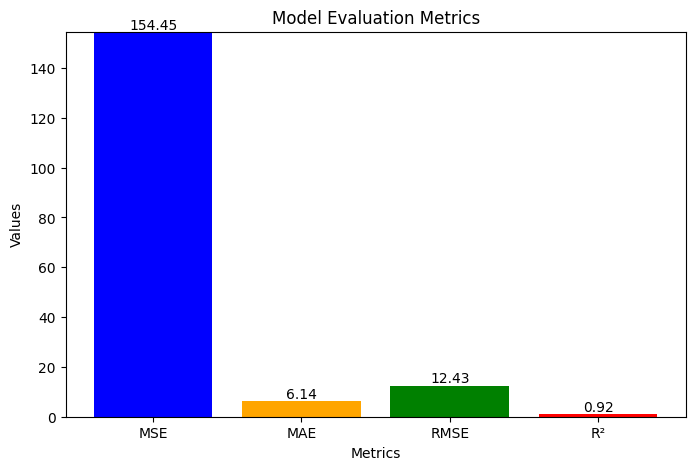

In [42]:
xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

# Fit basic XGBoost model
xgb_basic.fit(X_train, y_train)

# Predictions on test set
y_pred_basic = xgb_basic.predict(X_test)

# Evaluate metrics on test set
mse_basic = mean_squared_error(y_test, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
r2_basic = r2_score(y_test, y_pred_basic)
mae_basic = mean_absolute_error(y_test, y_pred_basic)

# Print performance results
print(f"Basic Model Performance:")
print(f"MSE: {mse_basic:.2f}")
print(f"RMSE: {rmse_basic:.2f}")
print(f"R² Score: {r2_basic:.3f}")
print(f"MAE: {mae_basic:.2f}")

# Prepare data for plotting
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse_basic, mae_basic, rmse_basic, r2_basic]

# Bar chart of evaluation metrics
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust y-axis and add metric values above bars
plt.ylim([0, max(values) + 0.1])
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

plt.show()




R² score of 0.92 is very good, because it means that the model can explain 92% of the data variance. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 105.57
Test MSE: 154.45
Train MAE: 5.71
Test MAE: 6.14
Train RMSE: 10.27
Test RMSE: 12.43
Train R² Score: 0.947
Test R² Score: 0.922


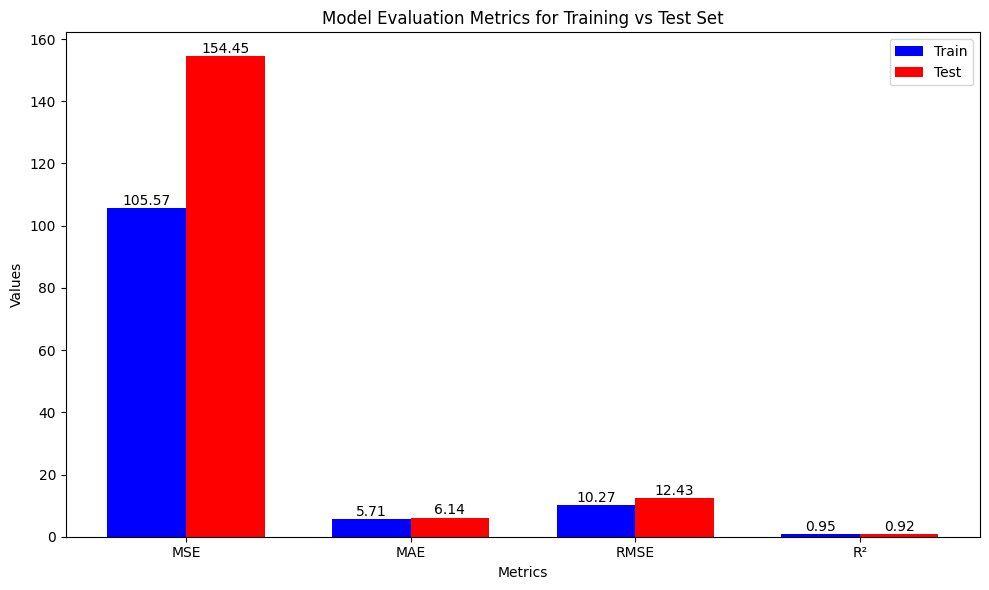

In [43]:
# Predictions for training and test sets
y_train_pred = xgb_basic.predict(X_train)
y_test_pred = xgb_basic.predict(X_test)

# Calculate MSE, MAE, RMSE, and R^2 for training and test sets
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# Prepare values for a train vs test comparison chart
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Create bar chart for comparison
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Labels, title, and legend
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Add metric values above bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.95 shows it explains 95% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.92, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

- The model captures the underlying relationship between vehicle characteristics and CO2 emissions very well
- Performance is consistent between training and test sets (no severe overfitting)
- Error levels are practically acceptable for most applications

However, The mild overfitting suggests hyperparameter tuning could help

In [44]:
# Perform 5-fold cross-validation using R^2 as the metric
cv_scores = cross_val_score(xgb_basic, X_train, y_train, cv=5, scoring='r2')

# Print all fold R^2 scores and their mean
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.3f}")

Cross-validated R² scores: [0.93313169 0.93874192 0.92551714 0.925372   0.92638141]
Mean CV R² score: 0.930


We see very similar pattern as Random Forest Model results. 

The overall performance of the model is strong. The model is well fitted and generalizes well. 

#### Hyperparameter Tuning

In [45]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 0.9, 1.0],
    'reg_alpha': [0.1, 1, 10],
    'reg_lambda': [1, 10, 100],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Define base XGBoost model
xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

# Run grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_basic,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit search on training data
grid_search.fit(X_train, y_train)

# Show best parameters and best R^2 score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)


Fitting 5 folds for each of 1458 candidates, totalling 7290 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 1.0}
Best cross-validated R² score: 0.9338001728057861


In [46]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

# Get the best XGBoost model from grid search
best_model_XGBoost = grid_search.best_estimator_

# Predictions on train and test sets
y_train_pred = best_model_XGBoost.predict(X_train)
y_test_pred = best_model_XGBoost.predict(X_test)

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print("\nFine-tuned Model Performance:")
print(f"Train MSE: {train_mse:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest MSE: {test_mse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R²: {test_r2:.3f}")


Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 1.0}
Best cross-validated R² score: 0.9338001728057861

Fine-tuned Model Performance:
Train MSE: 89.764
Train RMSE: 9.474
Train MAE: 4.998
Train R²: 0.955

Test MSE: 146.701
Test RMSE: 12.112
Test MAE: 5.622
Test R²: 0.926


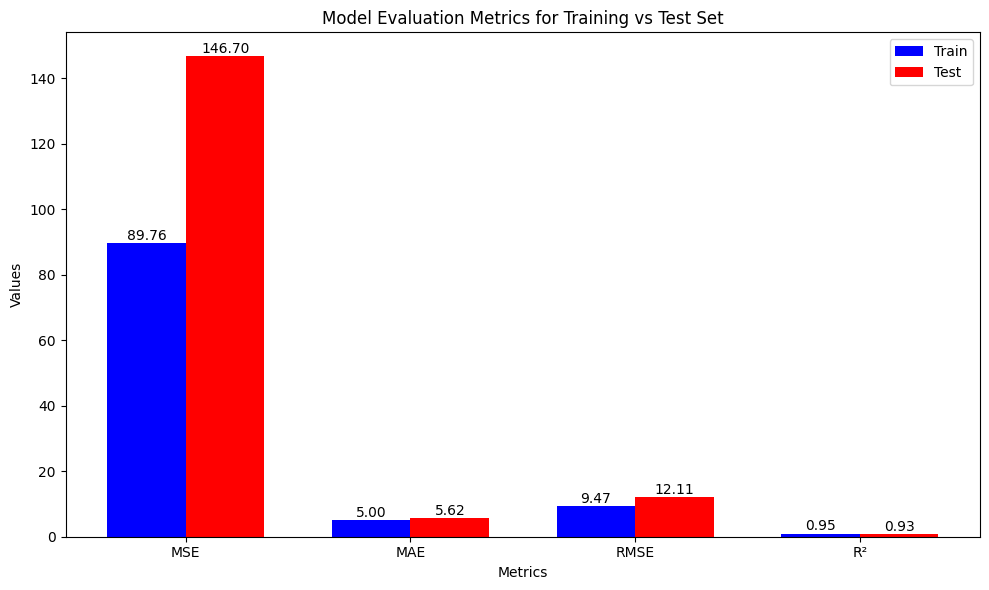

In [47]:
# Prepare metrics and corresponding values
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_rmse, train_r2]
test_values = [test_mse, test_mae, test_rmse, test_r2]

# Bar settings
bar_width = 0.35
index = np.arange(len(metrics))

# Create bar plot for train vs test metrics
plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Labels, title, and legend
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Add metric values above bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


Model Comparison and Evaluation

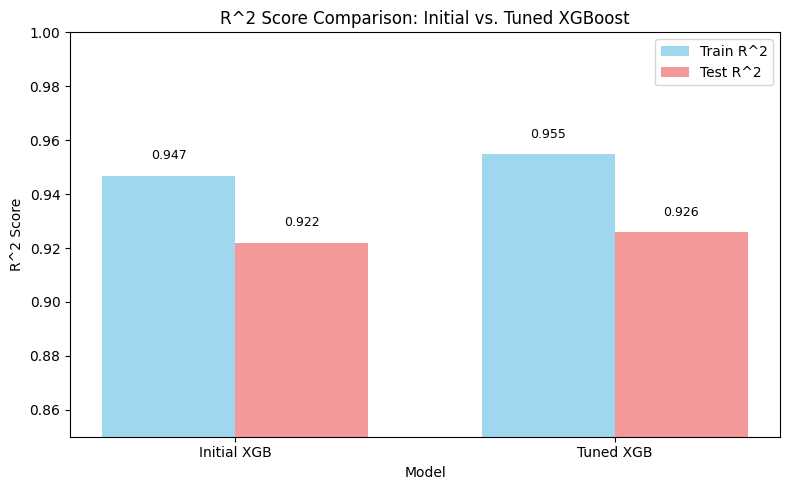

In [48]:
xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

# Fit the initial XGBoost model
xgb_basic.fit(X_train, y_train)
y_pred_basic = xgb_basic.predict(X_test)

# Calculate R^2 scores for initial and tuned models
initial_train_r2 = r2_score(y_train, xgb_basic.predict(X_train))
initial_test_r2 = r2_score(y_test, xgb_basic.predict(X_test))
tuned_train_r2 = r2_score(y_train, best_model_XGBoost.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_model_XGBoost.predict(X_test))

# Store results in a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Model': ['Initial XGB', 'Tuned XGB'],
    'Train_R2': [initial_train_r2, tuned_train_r2],
    'Test_R2': [initial_test_r2, tuned_test_r2]
})

# Plot R^2 comparison
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

axes.bar(x - width/2, train_r2_vals, width, label='Train R^2', alpha=0.8, color='skyblue')
axes.bar(x + width/2, test_r2_vals, width, label='Test R^2', alpha=0.8, color='lightcoral')

# Labels, title, ticks, and legend
axes.set_xlabel('Model')
axes.set_ylabel('R^2 Score')
axes.set_title('R^2 Score Comparison: Initial vs. Tuned XGBoost')
axes.set_xticks(x)
axes.set_xticklabels(models_names)
axes.legend()
axes.set_ylim([0.85, 1.0])

# Add exact values on top of bars
for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes.text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
              ha='center', va='bottom', fontsize=9)
    axes.text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


We have seen a slight overfitting reduction after hyperparameter tuning, but that also costs us some performance degradation. 


#### Saving the Model for Streamlit

In [49]:
# Save the model
joblib.dump(best_model_XGBoost, '../models/best_model_XGBoost.pkl')

['../models/best_model_XGBoost.pkl']

## Model 5 - Deep Learning model

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 

In [51]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Split features and target
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for neural network
scaler_dl = StandardScaler()
X_train_scaled = scaler_dl.fit_transform(X_train)
X_test_scaled = scaler_dl.transform(X_test)

# Define sequential deep learning model
dl_model = Sequential()

# Input layer
dl_model.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

# Hidden layers
dl_model.add(Dense(128, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(64, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dropout(0.1))

# Output layer
dl_model.add(Dense(1, activation='linear'))

# Compile model with Adam optimizer and MSE loss
dl_model.compile(optimizer=Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999),
                 loss='mse', metrics=['mae'])

print("Model Architecture:")
dl_model.summary()

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=30,
                               restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.8,
                              patience=15, min_lr=1e-7, verbose=1)

callbacks = [early_stopping, reduce_lr]

# Train model
history = dl_model.fit(X_train_scaled, y_train,
                       validation_split=0.2,
                       epochs=200,
                       batch_size=64,
                       callbacks=callbacks,
                       verbose=1)

# Predictions on test set
y_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.3f}")


c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,977 (183.50 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 21438.3906 - mae: 137.5464 - val_loss: 6887.4541 - val_mae: 76.1390 - learning_rate: 5.0000e-04
Epoch 2/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3531.5293 - mae: 46.7744 - val_loss: 443.8373 - val_mae: 14.4620 - learning_rate: 5.0000e-04
Epoch 3/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2185.8123 - mae: 36.1712 - val_loss: 418.2667 - val_mae: 13.8689 - learning_rate: 5.0000e-04
Epoch 4/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2125.5635 - mae: 35.6920 - val_loss: 429.8423 - val_mae: 14.0997 - learning_rate: 5.0000e-04
Epoch 5/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2049.4158 - mae: 35.0643 - val_loss: 415.5811 - val_mae: 13.5474 - learning_rate: 5.0000e-04
Epoch 6/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1962.0422 - mae: 34.1845 - val_loss: 391.1069 - val_mae: 12.8649 - learning_rate: 5.0000e-04
Epoch 7/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1829.1224 - 

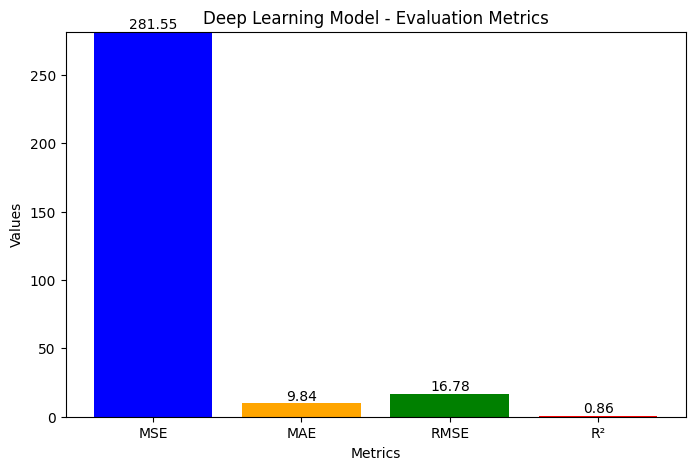

In [52]:
# Prepare metrics and values for visualization
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, rmse, r2]

# Create bar plot of evaluation metrics
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Deep Learning Model - Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust y-axis and add value labels above bars
plt.ylim([0, max(values) + 0.1])
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

plt.show()


Train MSE: 255.58
Test MSE: 281.55
Train MAE: 9.75
Test MAE: 9.84
Train RMSE: 15.99
Test RMSE: 16.78
Train R² Score: 0.871
Test R² Score: 0.858


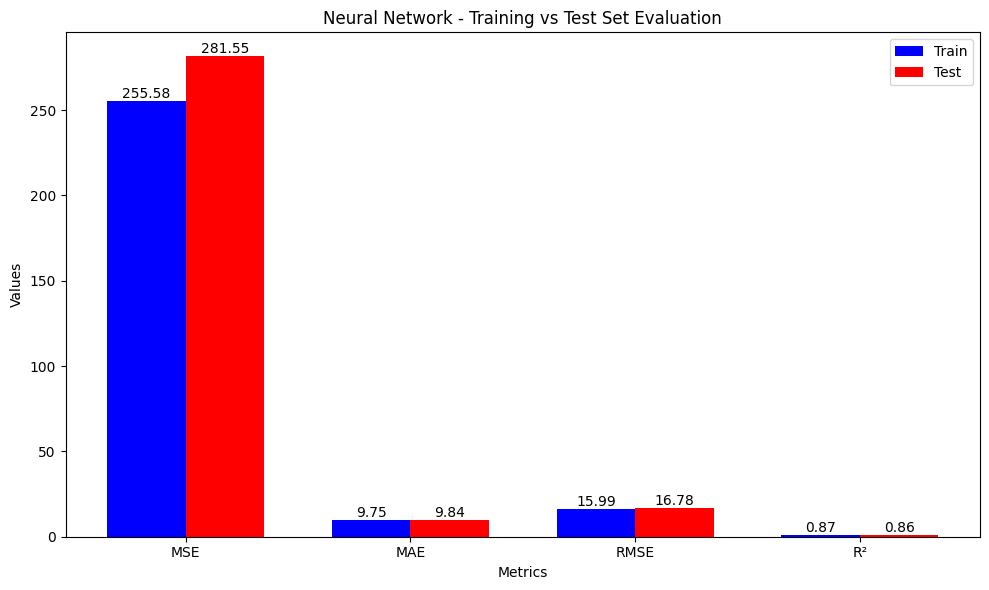

In [53]:
# Predictions for training and test sets
y_train_pred = dl_model.predict(X_train_scaled, verbose=0).flatten()
y_test_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Print evaluation results
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# Prepare values for bar chart comparison
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_rmse, train_r2]
test_values = [test_mse, test_mae, test_rmse, test_r2]

# Create bar chart for training vs test metrics
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Neural Network - Training vs Test Set Evaluation')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Add values above bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


We don't see much difference between training & validation results for MSE, MAE, and RMSE, indicating the model generalizes well, while the R² score of 0.87 shows it explains 87% of the variance in the training set.

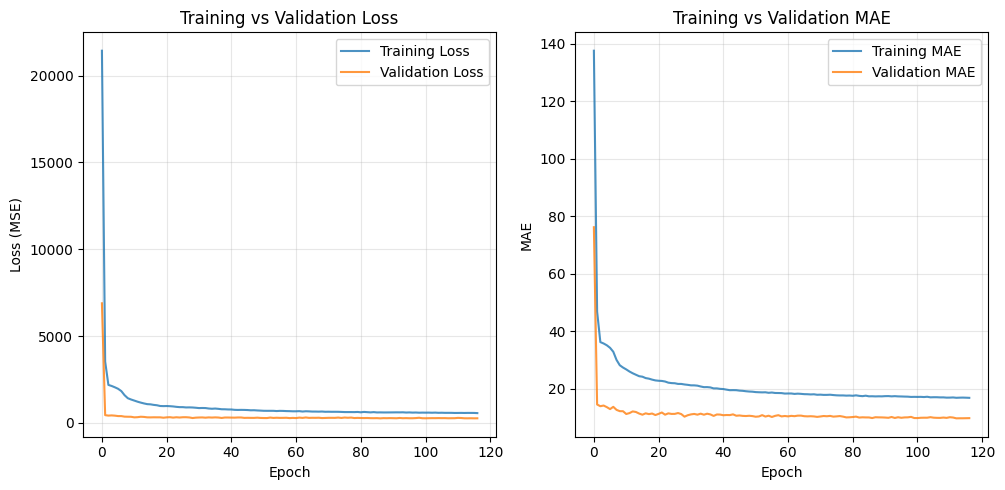

In [54]:

# Plot training history 
plt.figure(figsize=(15, 5))

# Training vs validation loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss', alpha=0.8)
plt.plot(history.history['val_loss'], label='Validation Loss', alpha=0.8)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Training vs validation MAE
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', alpha=0.8)
plt.plot(history.history['val_mae'], label='Validation MAE', alpha=0.8)
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate schedule 
if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'])
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Feature Importance Analysis

Feature Importance Rankings:
Mass_in_Running_Order(kg): 1.2645
Engine_Capacity(cm3): 1.0882
Engine_Power(kW): 0.4133
Fuel_Type_petrol: 0.1319


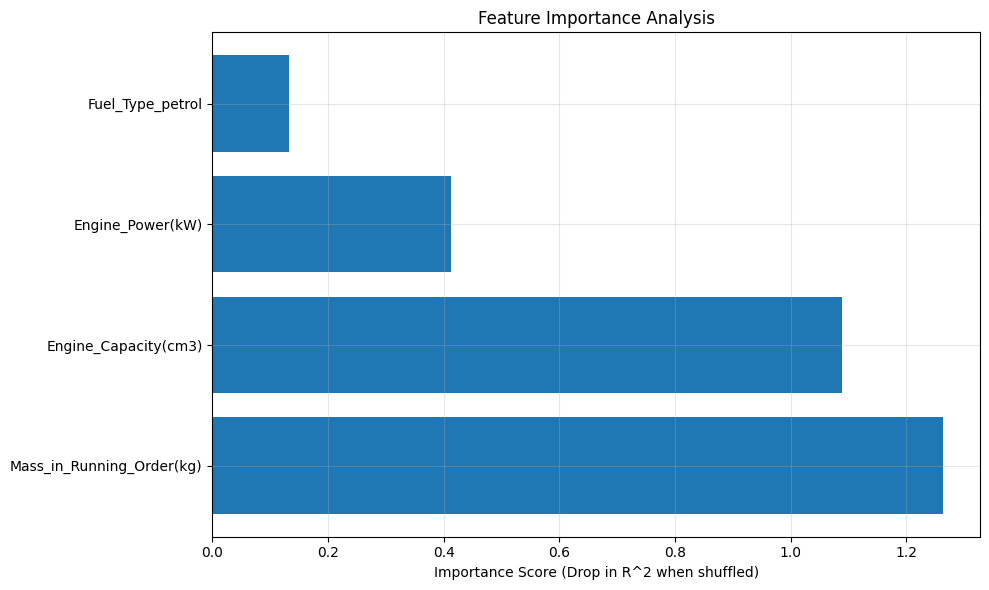

In [55]:
# Collect feature names
feature_names = X.columns.tolist()

# Baseline R^2 score with original data
baseline_score = r2_score(y_test, y_pred)
feature_importance = []

# Permutation feature importance loop
for i, feature in enumerate(feature_names):
    # Copy test data and shuffle one feature
    X_test_permuted = X_test_scaled.copy()
    np.random.shuffle(X_test_permuted[:, i])
    
    # Predict with shuffled feature
    y_pred_permuted = dl_model.predict(X_test_permuted, verbose=0).flatten()
    permuted_score = r2_score(y_test, y_pred_permuted)
    
    # Importance = drop in R^2 when feature is shuffled
    importance = baseline_score - permuted_score
    feature_importance.append(importance)

# Create DataFrame with feature importances
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Print ranking
print("Feature Importance Rankings:")
for idx, row in feature_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# Plot importance values
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_df)), feature_df['Importance'])
plt.yticks(range(len(feature_df)), feature_df['Feature'])
plt.xlabel('Importance Score (Drop in R^2 when shuffled)')
plt.title('Feature Importance Analysis')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Saving the model for Streamlit

In [56]:
# Save the scaler
joblib.dump(scaler_dl, '../models/scaler_dl.pkl')

# Save the model
joblib.dump(dl_model, '../models/dl_model.pkl')

['../models/dl_model.pkl']

## <span style="color:orange">Model Comparison & Conclusions</span>

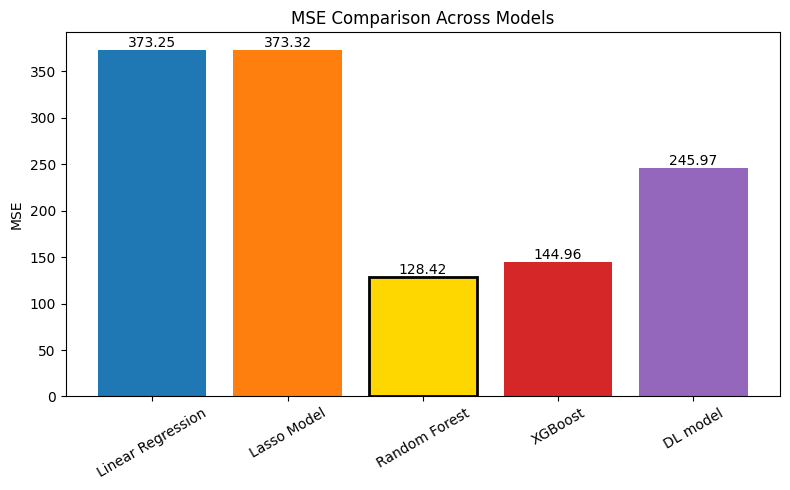

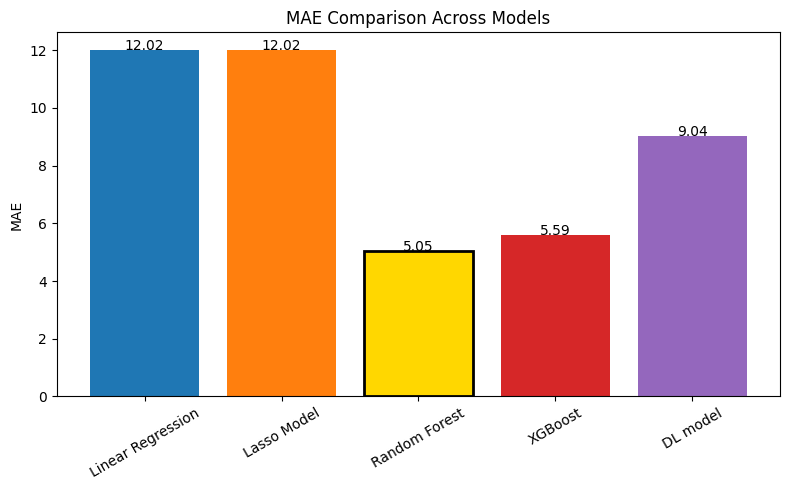

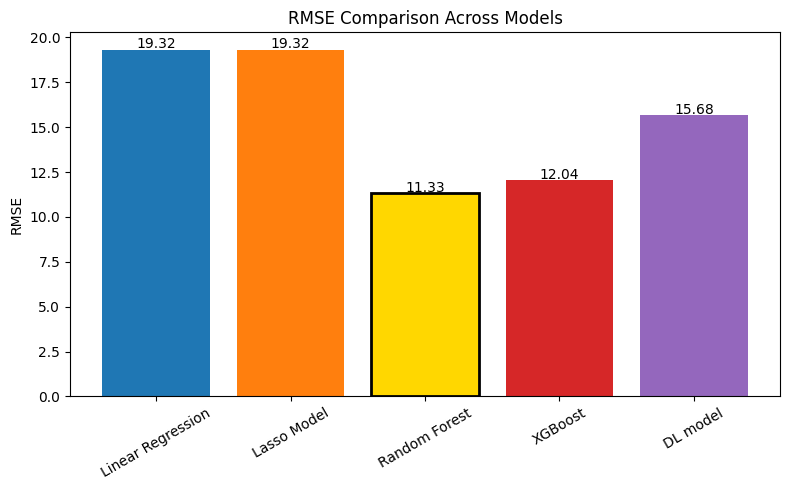

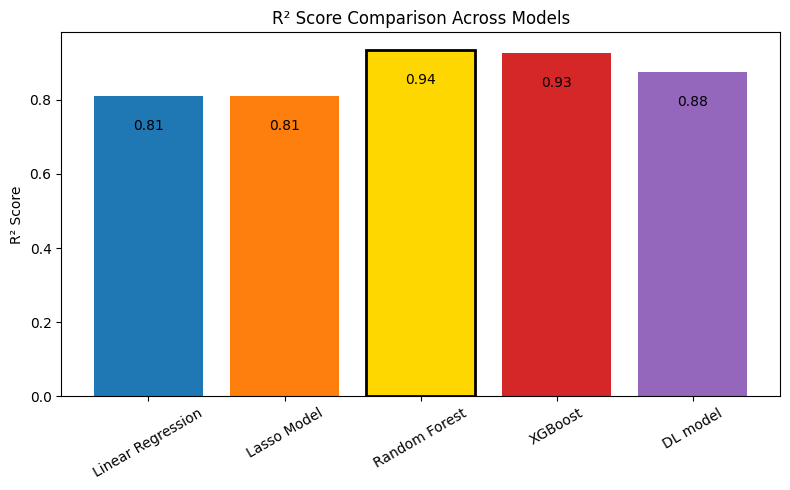

In [57]:
data = {
    "Metric": ["MSE", "MAE", "RMSE", "R² Score"],
    "Linear Regression": [373.25, 12.02, 19.32, 0.811],
    "Lasso Model": [373.32, 12.02, 19.32, 0.811],
    "Random Forest": [128.42, 5.05, 11.33, 0.935],
    "XGBoost": [144.96, 5.59, 12.04, 0.927],
    "DL model": [245.97, 9.04, 15.68, 0.876],
}


df = pd.DataFrame(data)
df.set_index("Metric", inplace=True)
models = df.columns

model_colors = {
    "Linear Regression":'#1f77b4',
    "Lasso Model": '#ff7f0e',
    "Random Forest": '#2ca02c',
    "XGBoost":  '#d62728',
    "DL model": '#9467bd'
}

for metric in df.index:
    plt.figure(figsize=(8, 5))
    
    values = df.loc[metric]
    bars = plt.bar(models, values, color=[model_colors[model] for model in models])
    
    if metric != "R² Score":
        best_model = values.idxmin()
    else:
        best_model = values.idxmax()
    
    best_idx = models.get_loc(best_model)
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval - 0.1, f"{yval:.2f}", ha='center', va='bottom')

    plt.title(f'{metric} Comparison Across Models')
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()



When we compare the all 5 models above then we see that Random Forest model's performance is better than XGBoost and others. Therefore, we will proceed next steps with Random Forest model


| Metric       | Linear Regression | Lasso Model | Random Forest | XGBoost | DL model | Winner              |
|--------------|-------------------|-------------|---------------|---------|----------|---------------------|
| **MSE**      | 373.25            | 373.32      | **128.42**    | 144.96  | 254.97   | 🏆**Random Forest** |
| **MAE**      | 12.02             | 12.02       | **5.05**      | 5.59    | 9.04     | 🏆**Random Forest** |
| **RMSE**     | 19.32             | 19.32       | **11.33**     | 12.04   | 15.68    | 🏆**Random Forest** |
| **R² Score** | 0.811             | 0.811       | **0.935**     | 0.927   | 0.876    | 🏆**Random Forest** |


Random Forest shows:

- 5.9% lower prediction error (RMSE improvement) than the second best model (XGBoost)
- 0.8% higher variance explained (R² improvement) than the second best model (XGBoost)

## SHAP Values

In [58]:
import joblib
import shap
import matplotlib.pyplot as plt


c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\silva\AppData\Local\Temp\ipykernel_9368\1615737731.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


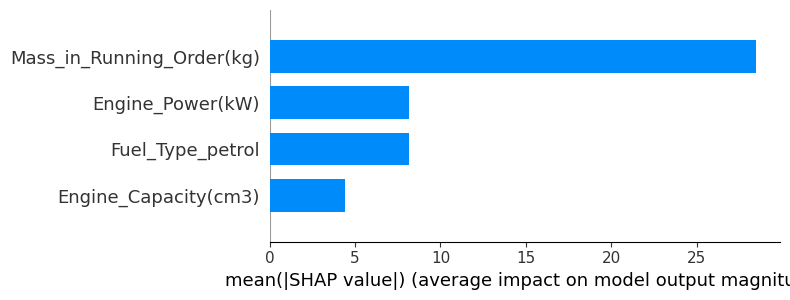

C:\Users\silva\AppData\Local\Temp\ipykernel_9368\1615737731.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


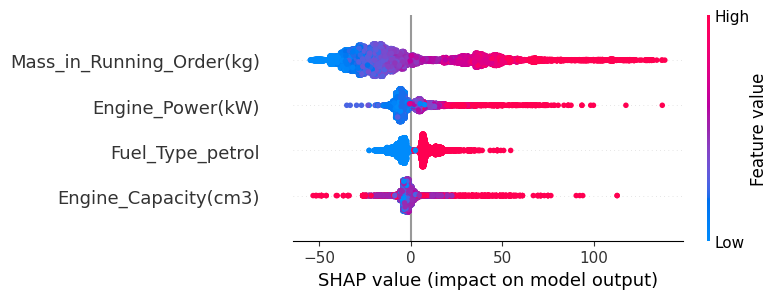

In [59]:

# Load the pre-trained Random Forest model with joblib
model_rf = joblib.load("../models/best_model_Random_Forest.pkl")

# Create a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(model_rf)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

# Plot a summary of feature importance (bar chart) and save it
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig("../plots/shap_summary_bar.png", bbox_inches='tight')
plt.show()
plt.close()

# Plot a detailed summary (shows feature impact direction) and save it
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("../plots/shap_summary_detailed.png", bbox_inches='tight')
plt.show()
plt.close()


Now we want to look at more specific values.

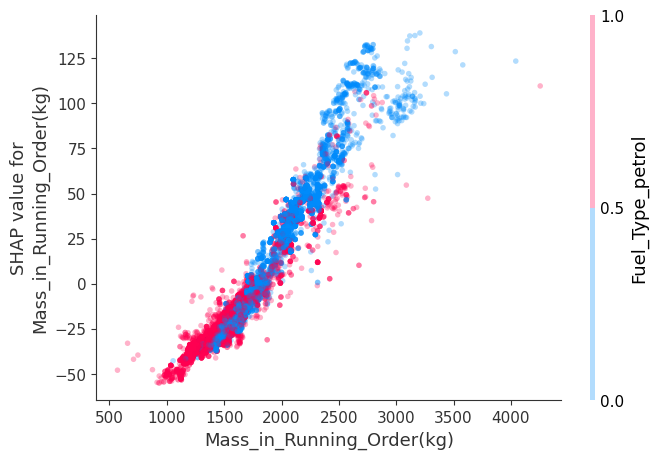

In [67]:
shap.dependence_plot("Mass_in_Running_Order(kg)", shap_values, X_test, interaction_index= "Fuel_Type_petrol", alpha=0.3)

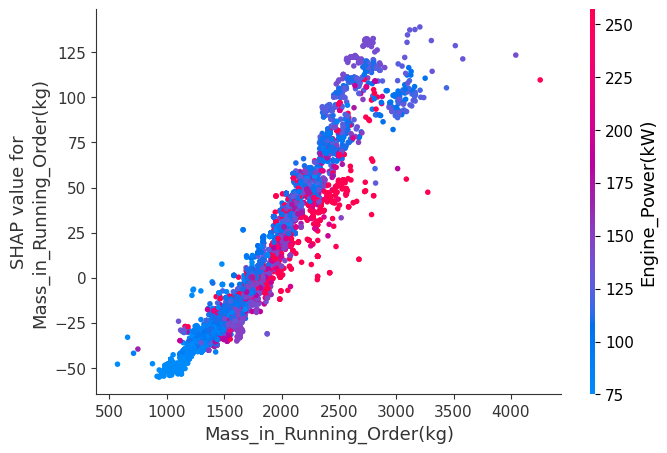

In [61]:
shap.dependence_plot("Mass_in_Running_Order(kg)", shap_values, X_test, interaction_index= "Engine_Power(kW)")

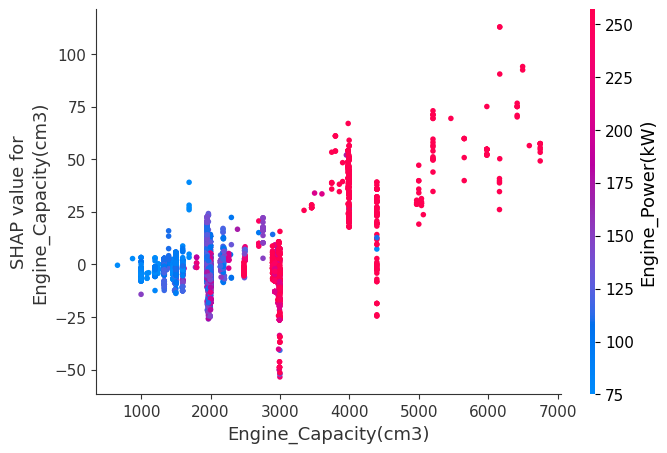

In [62]:
shap.dependence_plot("Engine_Capacity(cm3)", shap_values, X_test, interaction_index= "Engine_Power(kW)")


Sample 1


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
71571,1395,1332,110,1


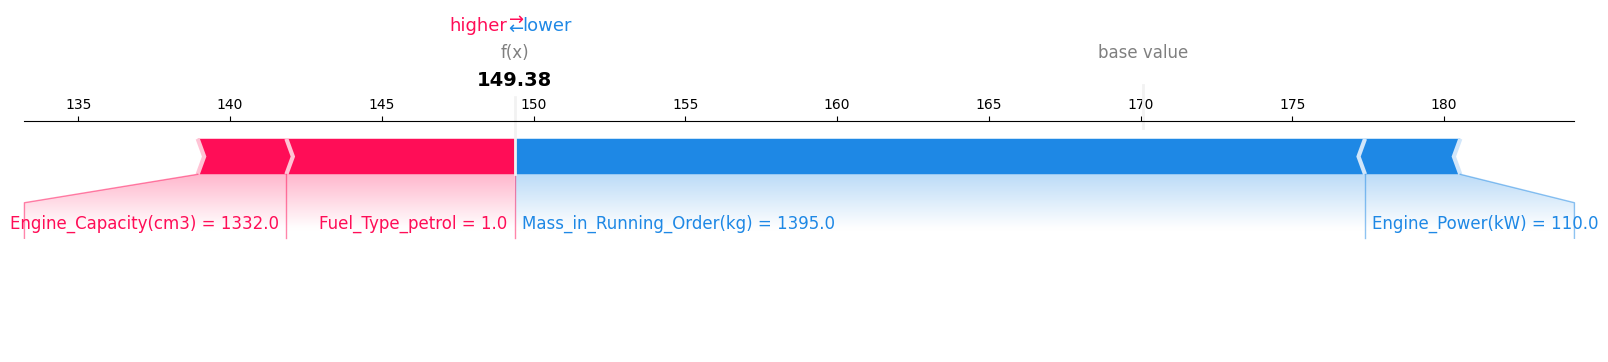


Sample 2


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
48335,1171,999,70,1


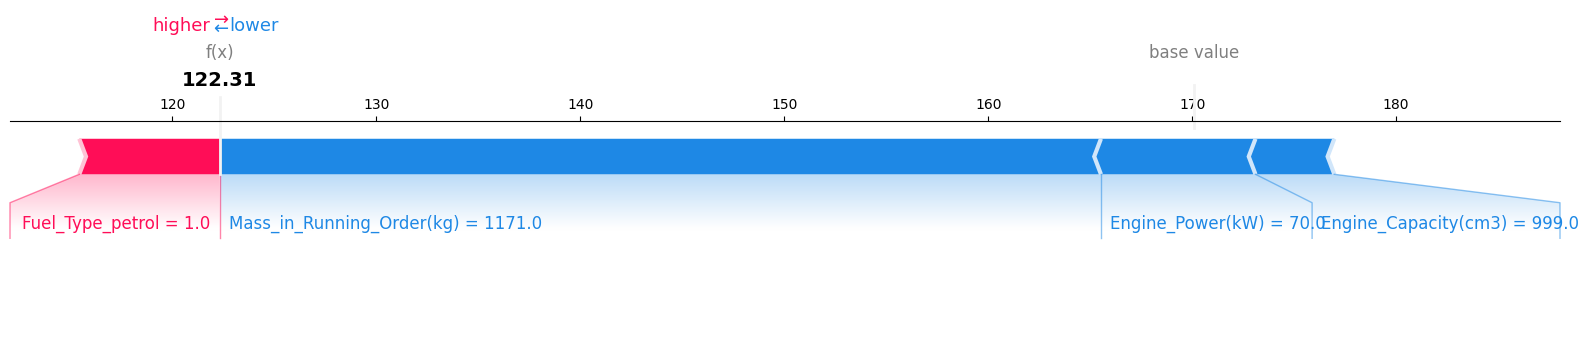


Sample 3


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
55028,1829,1968,147,0


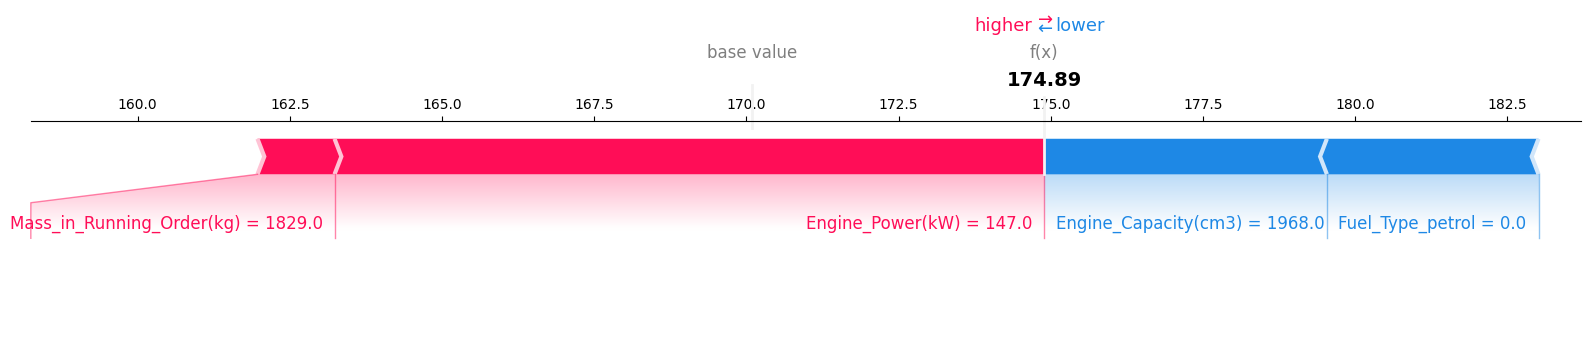


Sample 4


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
4245,1505,1998,131,1


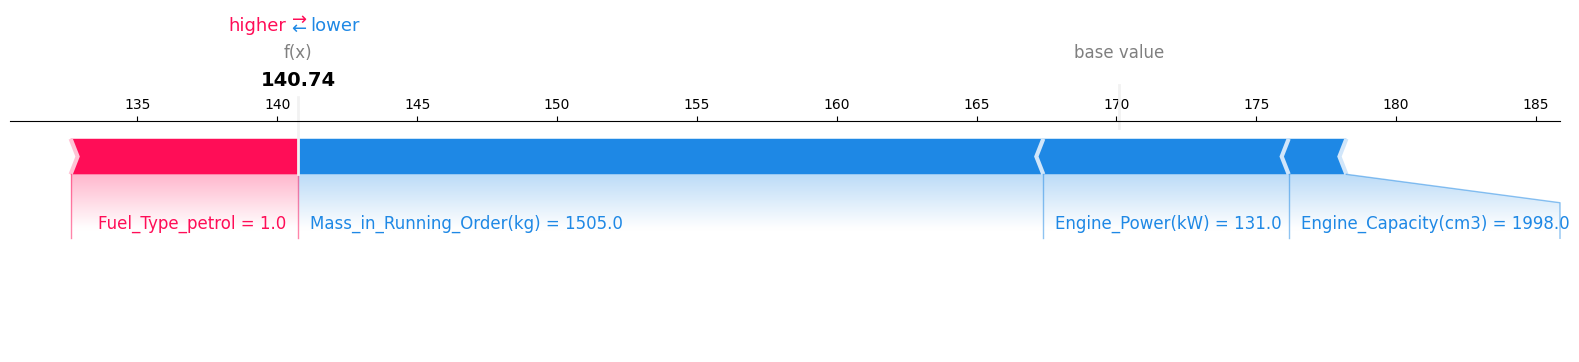


Sample 5


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
69739,1347,999,81,1


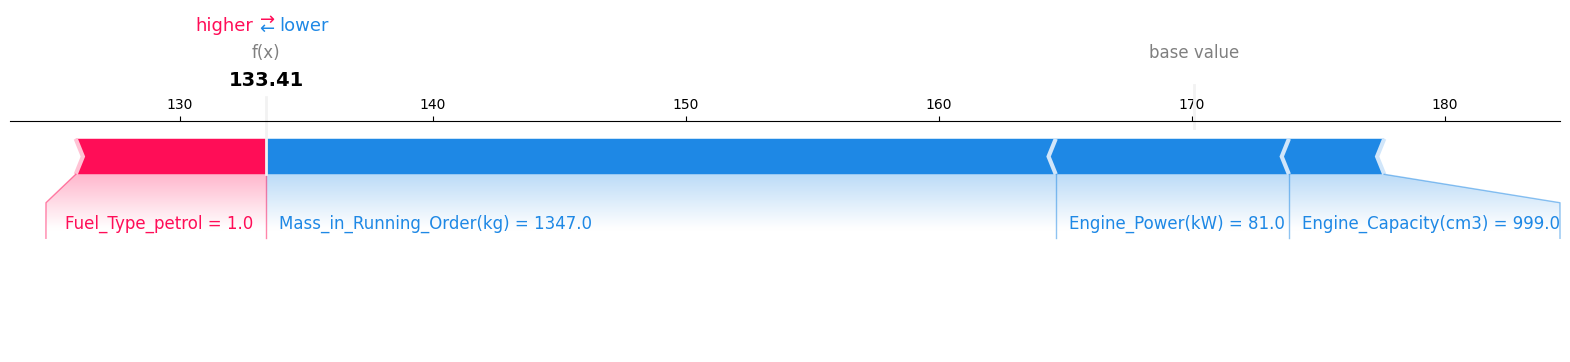

In [63]:
# 1. Randomly select 3–5 row positions (not indices) from the test set
n_samples = 5
random_positions = np.random.choice(len(X_test), size=n_samples, replace=False)
# 2. Subset by position
X_subset = X_test.iloc[random_positions]
shap_subset = shap_values[random_positions]
# 3. Loop through and plot
shap.initjs()
for i in range(n_samples):
    print(f"\nSample {i+1}")
    display(X_subset.iloc[i].to_frame().T)
    shap.force_plot(explainer.expected_value, shap_subset[i], X_subset.iloc[i], matplotlib=True)


=== Min CO₂ Emission (Predicted CO₂: 113.13 g/km) ===
Mass_in_Running_Order(kg): -42.64 (value: 1055)
Engine_Capacity(cm3): -2.39 (value: 1248)
Engine_Power(kW): -8.45 (value: 70)
Fuel_Type_petrol: -9.47 (value: 0)


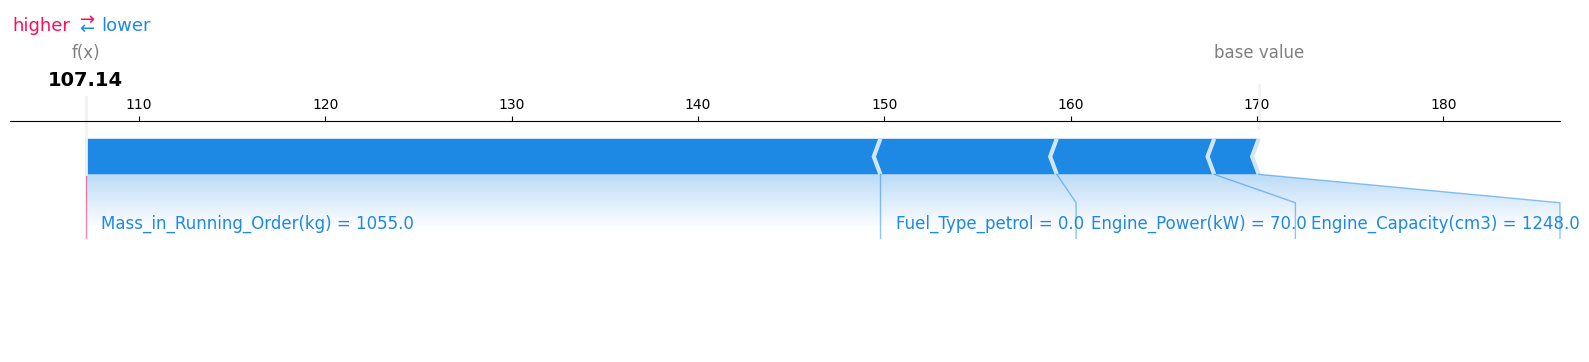


=== Median CO₂ Emission (Predicted CO₂: 156.83 g/km) ===
Mass_in_Running_Order(kg): -15.28 (value: 1673)
Engine_Capacity(cm3): -4.26 (value: 1968)
Engine_Power(kW): +9.75 (value: 147)
Fuel_Type_petrol: -3.15 (value: 0)


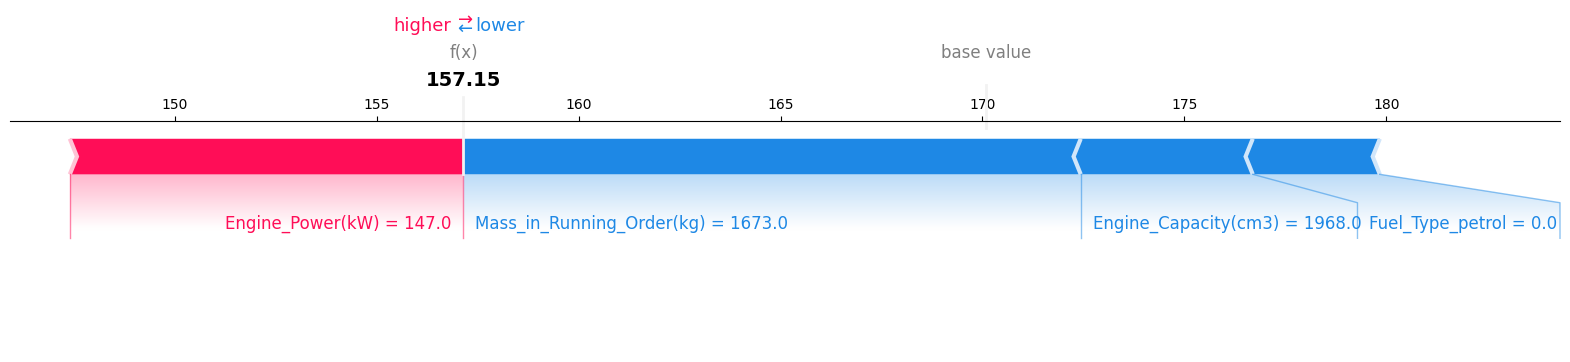


=== Mean CO₂ Emission (Predicted CO₂: 155.68 g/km) ===
Mass_in_Running_Order(kg): -11.07 (value: 1578)
Engine_Capacity(cm3): +2.19 (value: 1598)
Engine_Power(kW): -2.56 (value: 110)
Fuel_Type_petrol: +11.54 (value: 1)


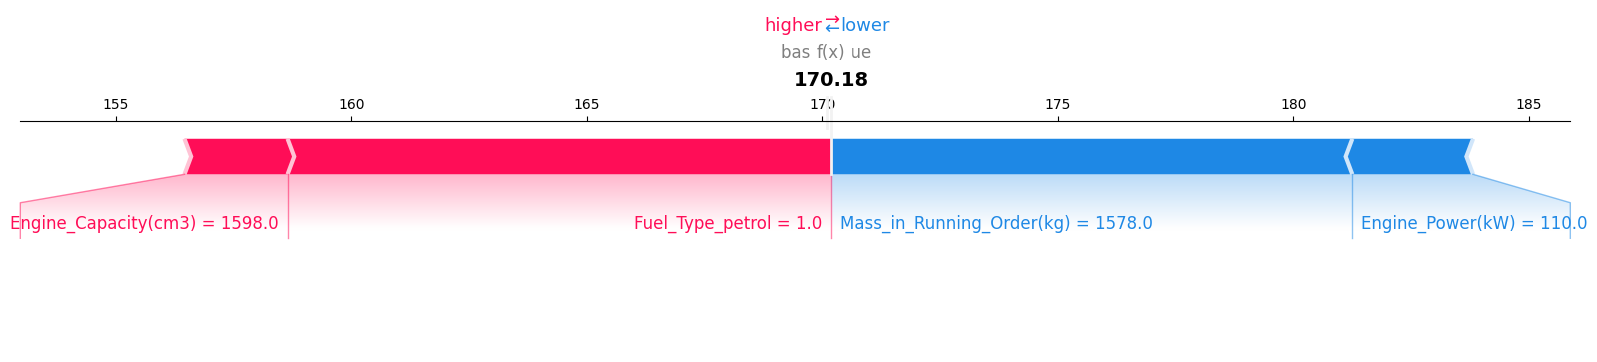


=== Max CO₂ Emission (Predicted CO₂: 561.49 g/km) ===
Mass_in_Running_Order(kg): +109.59 (value: 4255)
Engine_Capacity(cm3): +75.05 (value: 5980)
Engine_Power(kW): +38.22 (value: 450)
Fuel_Type_petrol: +27.28 (value: 1)


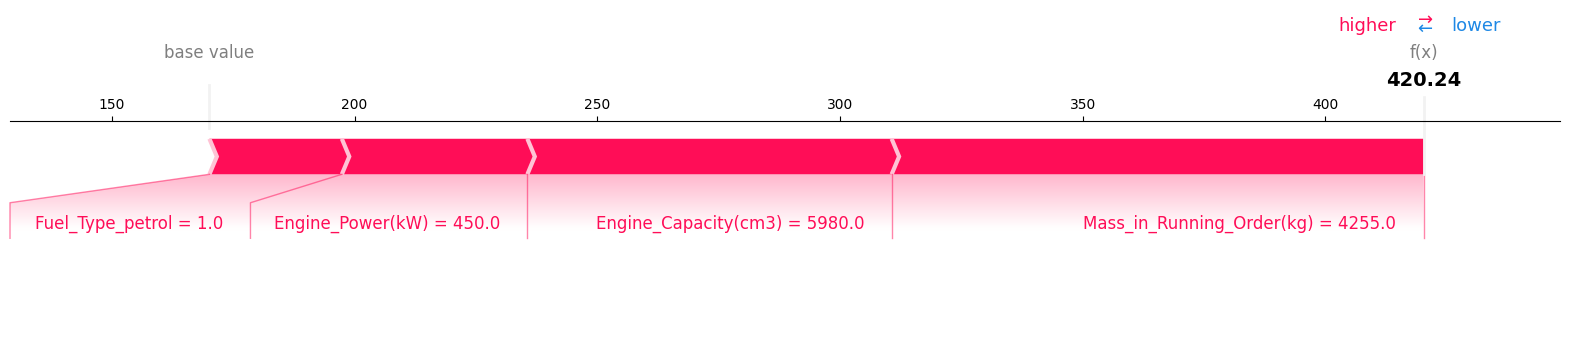

In [64]:
# Predict CO₂
y_test_pred_rf = model_rf.predict(X_test)
# Indices
min_idx = np.argmin(y_test_pred_rf)
max_idx = np.argmax(y_test_pred_rf)
median_val = np.median(y_test_pred_rf)
mean_val = np.mean(y_test_pred_rf)
median_idx = (np.abs(y_test_pred_rf - median_val)).argmin()
mean_idx = (np.abs(y_test_pred_rf - mean_val)).argmin()

# Set up labels and indices
selected_indices = [min_idx, median_idx, mean_idx, max_idx]
labels = ["Min CO₂ Emission", "Median CO₂ Emission", "Mean CO₂ Emission", "Max CO₂ Emission"]
# SHAP init
shap.initjs()
# Print SHAP values and show force plots
for i, idx in enumerate(selected_indices):
    label = labels[i]
    shap_val = shap_values[idx]
    feature_row = X_test.iloc[idx]
    print(f"\n=== {label} (Predicted CO₂: {y_test_pred[idx]:.2f} g/km) ===")
    for feature_name, shap_score, feature_value in zip(X_test.columns, shap_val, feature_row):
        sign = "+" if shap_score >= 0 else "-"
        print(f"{feature_name}: {sign}{abs(shap_score):.2f} (value: {feature_value})")
    # Show SHAP force plot
    shap.force_plot(
        base_value=explainer.expected_value,
        shap_values=shap_val,
        features=feature_row,
        matplotlib=True
    )

The SHAP analysis of our Random Forest model illustrates how key vehicle features contribute to the prediction of CO₂ emissions, both in typical and extreme cases. Across the spectrum of predictions—from minimum to maximum emissions—the model consistently attributes the largest influence to vehicle mass, engine capacity and engine power. Higher values in these features push emissions upward. For the Fuel type it is a bit tricky, although across the modeling dataset, petrol vehicles have a median CO₂ of 174.8 g/km, which is lower than diesel’s median of 164.9 g/km, we can see in this random shap analysis, that for the observed examples the fuel type 1 characteristic (gasoline) increase the value of the CO2. In other words, if you take a light diesel car and swap it for a petrol engine of the same mass/power, the petrol might have higher CO₂ for that config, giving a positive SHAP.

In order to measure the effect of the petrol and diesel we could see how the model predicts putting the value of Co2 if we flip only the fuel type for each car while keeping all other features identical

In [65]:
# X_test: test features incl. 'Fuel_Type_petrol'
# rf_model: trained model

def fuel_delta(model, X, col='Fuel_Type_petrol'):
    Xp = X.copy()
    Xd = X.copy()
    Xp[col] = 1  # petrol
    Xd[col] = 0  # diesel
    pred_p = model.predict(Xp)
    pred_d = model.predict(Xd)
    return pred_p - pred_d  # positive => petrol > diesel; negative => petrol < diesel

delta = fuel_delta(rf_model, X_test)

print("Mean effect (petrol - diesel):", np.mean(delta))
print("Median effect:", np.median(delta))
print("Pct where petrol > diesel:", (delta > 0).mean())
print("Pct where petrol < diesel:", (delta < 0).mean())

Mean effect (petrol - diesel): 16.25597411543784
Median effect: 16.287976190476172
Pct where petrol > diesel: 0.7858466834370449
Pct where petrol < diesel: 0.19349927181252483


with this we can conclude:
 - holding all other features the same, petrol versions are predicted to emit around 16 g/km more CO₂ than diesel.
 - in most matched-spec cases, petrol emits more CO2
 - in some configurations, petrol beats diesel.

This matches with reality because of thermal efficiency:

Diesel engines operate at higher compression ratios and are generally more fuel-efficient than petrol engines.

This means they use less fuel to produce the same mechanical work, so they emit less CO₂ per km (since CO₂ from combustion is directly proportional to fuel burned).